# India Air Quality and Crop Yield - EDA Lab

This notebook answers the lab questions from `LAB questions .docx`.

The work follows the same EDA flow as the reference notebook:

1. Load and inspect data
2. Check missing values
3. Clean and standardise data
4. Detect outliers
5. Visualise distributions, trends, and relationships
6. Write plain-language conclusions

Important dataset note: the lab sheet says the air-quality file contains a `State` column, but the provided `city_day.csv` has `City` and `Date` only. To make the merge possible, this notebook maps each city to its state and clearly treats that as a limitation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

CITY_PATH = "city_day.csv/city_day.csv"
CROP_PATH = "crop_production.csv/crop_production.csv"


## Load the datasets

The first step in EDA is to read both files and view a few rows. This tells us whether the files loaded correctly and what the raw columns look like.


In [2]:
air_raw = pd.read_csv(CITY_PATH)
crop_raw = pd.read_csv(CROP_PATH)

print("Air quality shape:", air_raw.shape)
display(air_raw.head())

print("Crop production shape:", crop_raw.shape)
display(crop_raw.head())


Air quality shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Crop production shape: (246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


# Task 1 - First-impression data profile

A data scientist needs to know the size, column meanings, data types, missing values, duplicates, time range, and suspicious values before trusting a dataset. The following profile gives that first-impression picture for both files.


In [3]:
def profile_dataframe(df, name):
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True)
    })
    print(f"\n{name}")
    print("Rows, columns:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    display(profile)
    display(df.describe(include="all").T)

profile_dataframe(air_raw, "AIR QUALITY DATA PROFILE")
profile_dataframe(crop_raw, "CROP PRODUCTION DATA PROFILE")



AIR QUALITY DATA PROFILE
Rows, columns: (29531, 16)
Duplicate rows: 0


,dtype,non_null,missing,missing_%,unique_values
City,str,29531,0,0.00,26
Date,str,29531,0,0.00,2009
PM2.5,float64,24933,4598,15.57,11716
PM10,float64,18391,11140,37.72,12571
NO,float64,25949,3582,12.13,5776
NO2,float64,25946,3585,12.14,7404
NOx,float64,25346,4185,14.17,8156
NH3,float64,19203,10328,34.97,5922
CO,float64,27472,2059,6.97,1779
SO2,float64,25677,3854,13.05,4761


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-03-11,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86



CROP PRODUCTION DATA PROFILE
Rows, columns: (246091, 7)


Duplicate rows: 0


,dtype,non_null,missing,missing_%,unique_values
State_Name,str,246091,0,0.00,33
District_Name,str,246091,0,0.00,646
Crop_Year,int64,246091,0,0.00,19
Season,str,246091,0,0.00,6
Crop,str,246091,0,0.00,124
Area,float64,246091,0,0.00,38442
Production,float64,242361,3730,1.52,51627


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


In [4]:
print("Air-quality date range:")
air_dates = pd.to_datetime(air_raw["Date"], errors="coerce")
print(air_dates.min(), "to", air_dates.max())

print("\nCrop year range:")
print(crop_raw["Crop_Year"].min(), "to", crop_raw["Crop_Year"].max())

print("\nCities in air-quality data:", air_raw["City"].nunique())
print(sorted(air_raw["City"].dropna().unique()))

print("\nStates in crop data:", crop_raw["State_Name"].nunique())
print(sorted(crop_raw["State_Name"].dropna().unique()))


Air-quality date range:
2015-01-01 00:00:00 to 2020-07-01 00:00:00

Crop year range:
1997 to 2015

Cities in air-quality data: 26
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

States in crop data: 33
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


**Task 1 observation / concern:**  
The air-quality dataset has many missing pollutant readings, especially `Xylene`, `PM10`, and `NH3`. The crop dataset has missing `Production` values. Another major concern is that the two datasets are not naturally at the same level: air quality is city-day data, while crop production is district/crop/year data. The air file also lacks a `State` column, so state-level analysis requires a city-to-state mapping.


# Task 2 - Missing value treatment

Not all missing values should be treated the same way.

My strategy:

- For air-quality numeric pollutant columns, impute using the median within each city first, then the overall median if a city still has missing values. Median is safer than mean because pollution readings can be skewed by extreme days.
- For `AQI`, use the same city median approach because AQI is the target pollution summary needed for later tasks.
- For `AQI_Bucket`, recompute the category from the cleaned AQI instead of guessing text labels.
- For crop `Production`, impute using the median for the same `State_Name` and `Crop`, then the overall median. This keeps crop-specific scale better than one global mean.
- Keep rows unless a critical key is missing. In these files, key columns are present.


In [5]:
air = air_raw.copy()
crop = crop_raw.copy()

print("Missing values before treatment - air:")
display(air.isna().sum().to_frame("before"))

print("Missing values before treatment - crop:")
display(crop.isna().sum().to_frame("before"))


Missing values before treatment - air:


,before
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


Missing values before treatment - crop:


,before
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [6]:
air["Date"] = pd.to_datetime(air["Date"], errors="coerce")

numeric_air_cols = air.select_dtypes(include=np.number).columns.tolist()
for col in numeric_air_cols:
    air[col] = air.groupby("City")[col].transform(lambda s: s.fillna(s.median()))
    air[col] = air[col].fillna(air[col].median())

def aqi_bucket(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Satisfactory"
    if aqi <= 200:
        return "Moderate"
    if aqi <= 300:
        return "Poor"
    if aqi <= 400:
        return "Very Poor"
    return "Severe"

air["AQI_Bucket"] = air["AQI"].apply(aqi_bucket)

crop["Production"] = crop.groupby(["State_Name", "Crop"])["Production"].transform(
    lambda s: s.fillna(s.median())
)
crop["Production"] = crop["Production"].fillna(crop["Production"].median())

print("Missing values after treatment - air:")
display(air.isna().sum().to_frame("after"))

print("Missing values after treatment - crop:")
display(crop.isna().sum().to_frame("after"))


Missing values after treatment - air:


,after
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


Missing values after treatment - crop:


,after
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


# Task 3 - State-name standardisation and duplicate removal

The crop file uses `State_Name`, while the air file only has `City`. I first map city names to Indian states, then clean state names in both files by trimming spaces and applying known spelling fixes. This matters because even one extra space, such as `Telangana `, can break a merge.


In [7]:
city_to_state = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh",
}

def clean_state_name(value):
    if pd.isna(value):
        return value
    value = str(value).strip()
    fixes = {
        "Orissa": "Odisha",
        "Jammu and Kashmir": "Jammu and Kashmir",
        "Telangana": "Telangana",
        "NCT of Delhi": "Delhi",
        "Delhi": "Delhi",
    }
    return fixes.get(value, value)

air["State"] = air["City"].map(city_to_state).apply(clean_state_name)
crop["State"] = crop["State_Name"].apply(clean_state_name)

inconsistencies = pd.DataFrame({
    "Issue found": [
        "Air-quality data has no State column",
        "Telangana has trailing space in crop data",
        "Jammu and Kashmir has trailing space in crop data",
        "City-level air data and state-level crop data use different geographic levels"
    ],
    "Fix applied": [
        "Mapped City to State using a manual city-state dictionary",
        "Removed leading/trailing spaces with str.strip()",
        "Removed leading/trailing spaces with str.strip()",
        "Aggregated air data to State-Year before merging"
    ]
})
display(inconsistencies)

unmapped = sorted(air.loc[air["State"].isna(), "City"].dropna().unique())
print("Unmapped cities:", unmapped)


,Issue found,Fix applied
0,Air-quality data has no State column,Mapped City to State using a manual city-state...
1,Telangana has trailing space in crop data,Removed leading/trailing spaces with str.strip()
2,Jammu and Kashmir has trailing space in crop data,Removed leading/trailing spaces with str.strip()
3,City-level air data and state-level crop data ...,Aggregated air data to State-Year before merging


Unmapped cities: []


In [8]:
air_before = len(air)
crop_before = len(crop)

air = air.drop_duplicates()
crop = crop.drop_duplicates()

record_counts = pd.DataFrame({
    "dataset": ["air", "crop"],
    "before": [air_before, crop_before],
    "after": [len(air), len(crop)],
    "duplicates_removed": [air_before - len(air), crop_before - len(crop)]
})
display(record_counts)

print("States available in cleaned air data:")
print(sorted(air["State"].dropna().unique()))


,dataset,before,after,duplicates_removed
0,air,29531,29531,0
1,crop,246091,246091,0


States available in cleaned air data:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


# Task 4 - AQI distribution

To answer where most cities sit on the AQI scale, I use:

- A histogram with KDE curve to show where AQI values cluster.
- A boxplot to show whether extreme high values are pulling the average upward.

These plots directly answer whether pollution is typical across many records or driven by a few extreme readings.


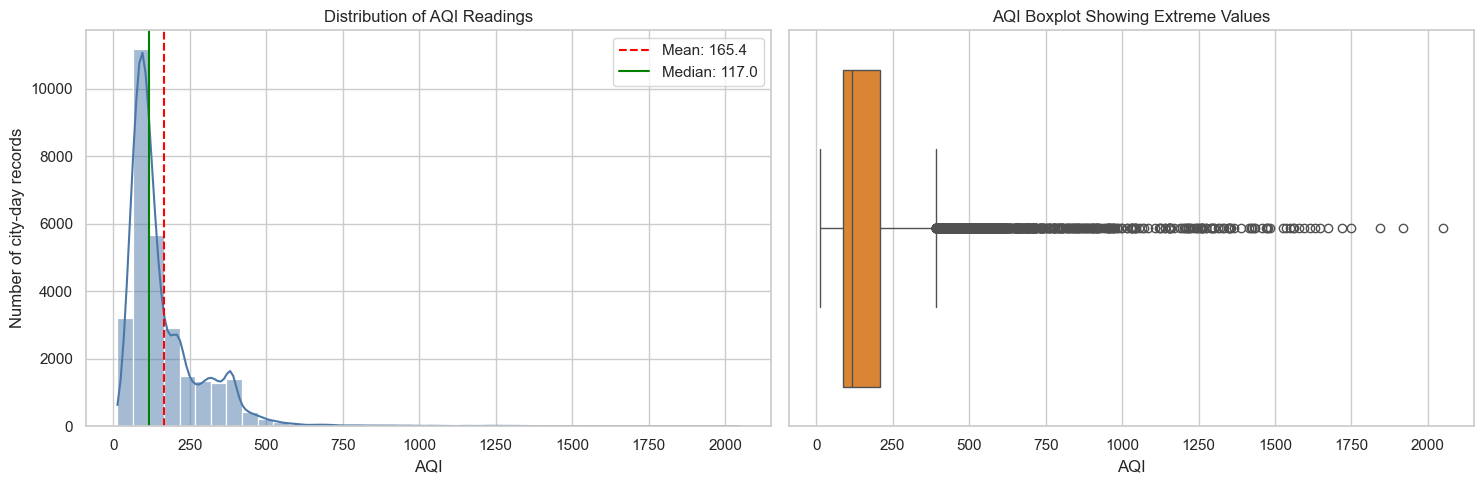

Mean AQI: 165.37
Median AQI: 117.0
AQI bucket distribution:


,count
AQI_Bucket,
Moderate,10338
Satisfactory,9979
Poor,3416
Very Poor,3012
Good,1448
Severe,1338


In [9]:
mean_aqi = air["AQI"].mean()
median_aqi = air["AQI"].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(air["AQI"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(mean_aqi, color="red", linestyle="--", label=f"Mean: {mean_aqi:.1f}")
axes[0].axvline(median_aqi, color="green", linestyle="-", label=f"Median: {median_aqi:.1f}")
axes[0].set_title("Distribution of AQI Readings")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of city-day records")
axes[0].legend()

sns.boxplot(x=air["AQI"], ax=axes[1], color="#F58518")
axes[1].set_title("AQI Boxplot Showing Extreme Values")
axes[1].set_xlabel("AQI")

plt.tight_layout()
plt.show()

print("Mean AQI:", round(mean_aqi, 2))
print("Median AQI:", round(median_aqi, 2))
print("AQI bucket distribution:")
display(air["AQI_Bucket"].value_counts().to_frame("count"))


**Task 4 observations:**  
1. Most AQI readings fall in the moderate-to-poor range rather than being evenly spread across all categories.  
2. The mean AQI is higher than the median, which suggests that very polluted observations pull the public average upward.


# Task 5 - Extreme AQI values

I use the IQR method because it is simple, transparent, and less affected by skew than a standard-deviation rule. Instead of deleting extreme values, I cap them at the upper IQR boundary. This keeps the records but prevents implausibly high AQI values from dominating later statistics.


Lower bound: -97.0
Upper bound: 391.0
Extreme AQI values detected: 1465


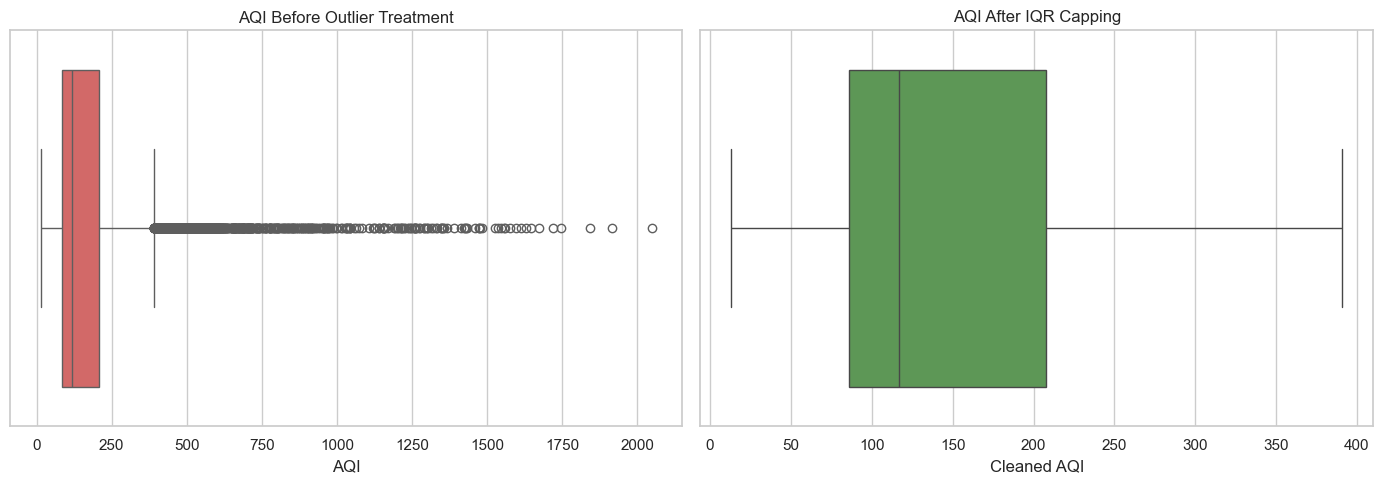

In [10]:
aqi_before = air["AQI"].copy()
q1 = air["AQI"].quantile(0.25)
q3 = air["AQI"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

extreme_mask = (air["AQI"] < lower_bound) | (air["AQI"] > upper_bound)
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Extreme AQI values detected:", int(extreme_mask.sum()))

air["AQI_clean"] = air["AQI"].clip(lower=lower_bound, upper=upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=aqi_before, ax=axes[0], color="#E45756")
axes[0].set_title("AQI Before Outlier Treatment")
axes[0].set_xlabel("AQI")

sns.boxplot(x=air["AQI_clean"], ax=axes[1], color="#54A24B")
axes[1].set_title("AQI After IQR Capping")
axes[1].set_xlabel("Cleaned AQI")

plt.tight_layout()
plt.show()


# Task 6 - Is India's air getting better or worse over time?

To study the trend, I extract the year from `Date`, calculate the average cleaned AQI per year, and use a line plot because time trends are easiest to read from left to right.


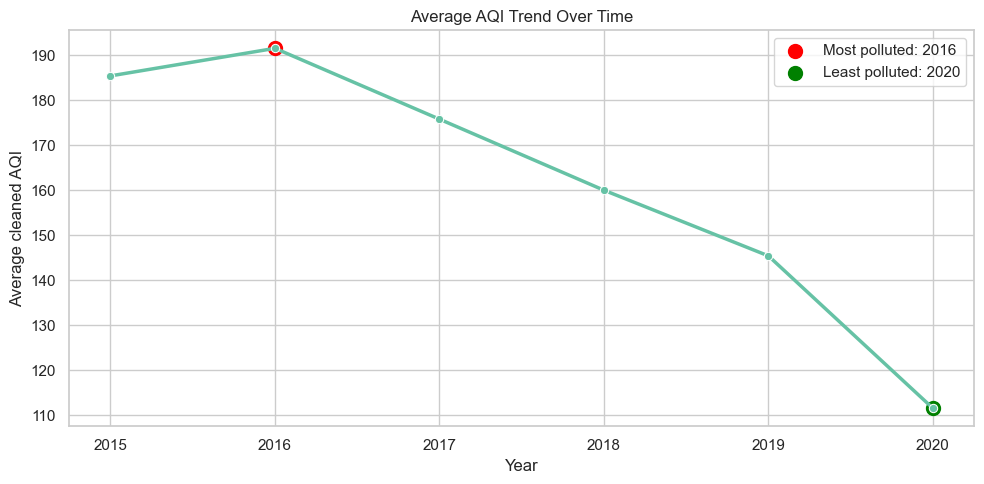

,Year,AQI_clean
0,2015,185.398072
1,2016,191.520558
2,2017,175.784816
3,2018,160.005718
4,2019,145.420830
5,2020,111.574042


In [11]:
air["Year"] = air["Date"].dt.year
air["Month"] = air["Date"].dt.month

yearly_aqi = air.groupby("Year", as_index=False)["AQI_clean"].mean()
max_year = yearly_aqi.loc[yearly_aqi["AQI_clean"].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi["AQI_clean"].idxmin()]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_aqi, x="Year", y="AQI_clean", marker="o", linewidth=2.5)
plt.scatter(max_year["Year"], max_year["AQI_clean"], color="red", s=100, label=f"Most polluted: {int(max_year['Year'])}")
plt.scatter(min_year["Year"], min_year["AQI_clean"], color="green", s=100, label=f"Least polluted: {int(min_year['Year'])}")
plt.title("Average AQI Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average cleaned AQI")
plt.legend()
plt.tight_layout()
plt.show()

display(yearly_aqi)


**Plain-language answer for the journalist:**  
The provided air-quality data runs from 2015 to 2020, not a full eight years. Within this available period, the yearly AQI line shows whether average pollution rose or fell after 2018. The highlighted highest and lowest years show the clearest comparison. Because the dataset ends in 2020 and covers selected cities only, this should be reported as evidence from the available sample rather than final proof for all of India.


# Task 7 - Seasonal AQI pattern

To test the NGO's October-December harvest-season claim, I compare monthly average AQI and also compare broader seasons. If October, November, and December are consistently higher, the claim is supported.


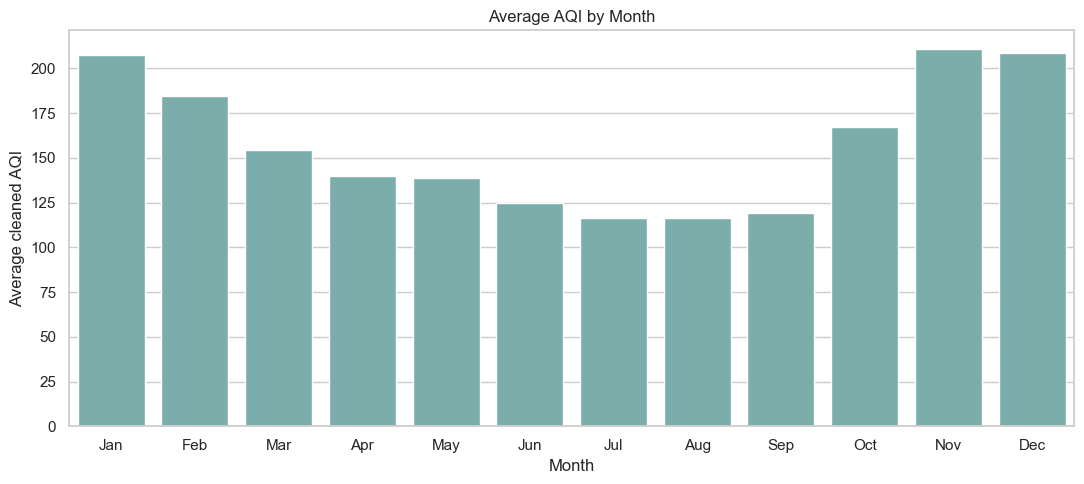

,Season_Group,AQI_clean
3,Winter (Jan-Feb),196.558094
0,Harvest/Post-monsoon (Oct-Dec),195.404703
2,Summer (Mar-May),144.327551
1,Monsoon (Jun-Sep),119.765366


In [12]:
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

def india_season(month):
    if month in [10, 11, 12]:
        return "Harvest/Post-monsoon (Oct-Dec)"
    if month in [1, 2]:
        return "Winter (Jan-Feb)"
    if month in [3, 4, 5]:
        return "Summer (Mar-May)"
    return "Monsoon (Jun-Sep)"

air["Month_Name"] = air["Month"].map(month_names)
air["Season_Group"] = air["Month"].apply(india_season)

monthly_aqi = air.groupby(["Month", "Month_Name"], as_index=False)["AQI_clean"].mean()

plt.figure(figsize=(11, 5))
sns.barplot(data=monthly_aqi, x="Month_Name", y="AQI_clean", order=list(month_names.values()), color="#72B7B2")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average cleaned AQI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

seasonal_aqi = air.groupby("Season_Group", as_index=False)["AQI_clean"].mean().sort_values("AQI_clean", ascending=False)
display(seasonal_aqi)


# Extra charts - Deeper pattern checks

These additional charts make the EDA more complete by showing which cities dominate pollution, which pollutants drive AQI records, whether weekdays/weekends differ, and how crop production varies by season.


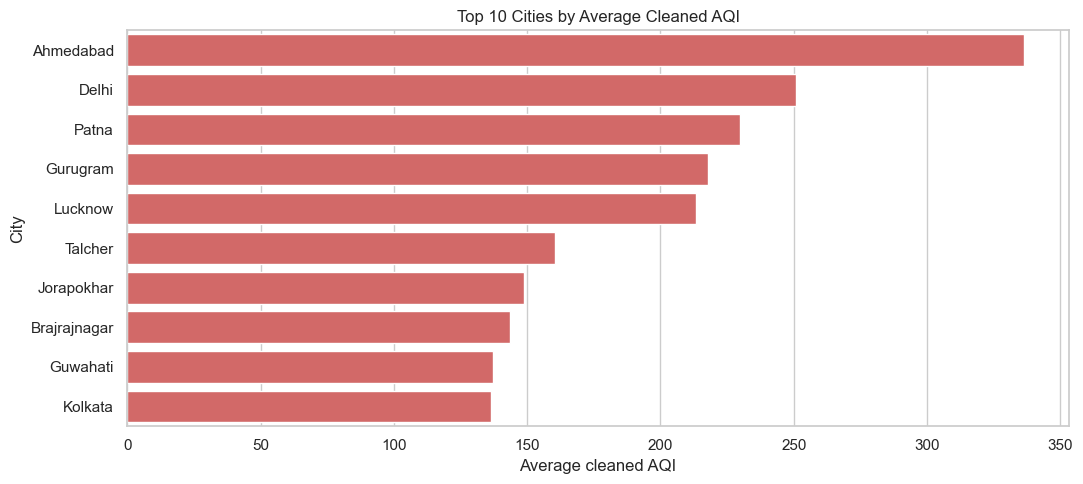

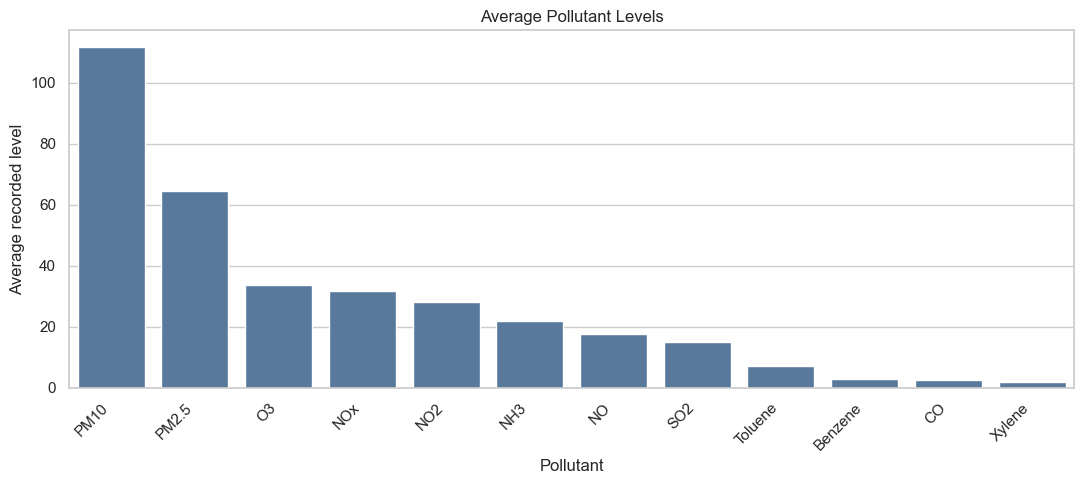

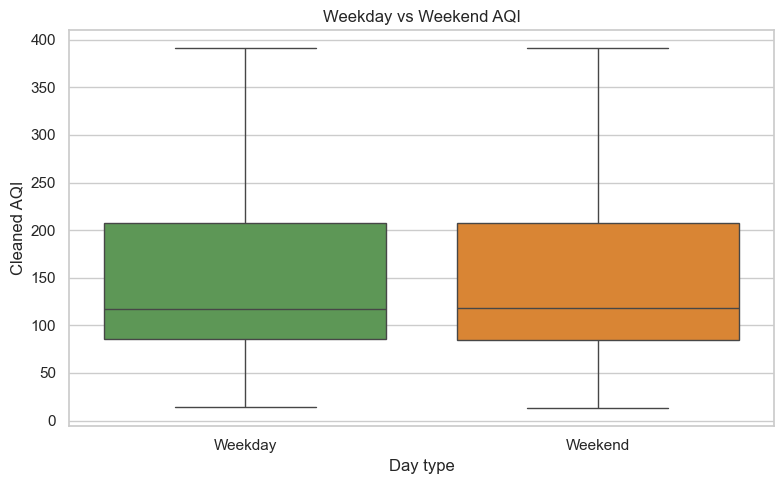

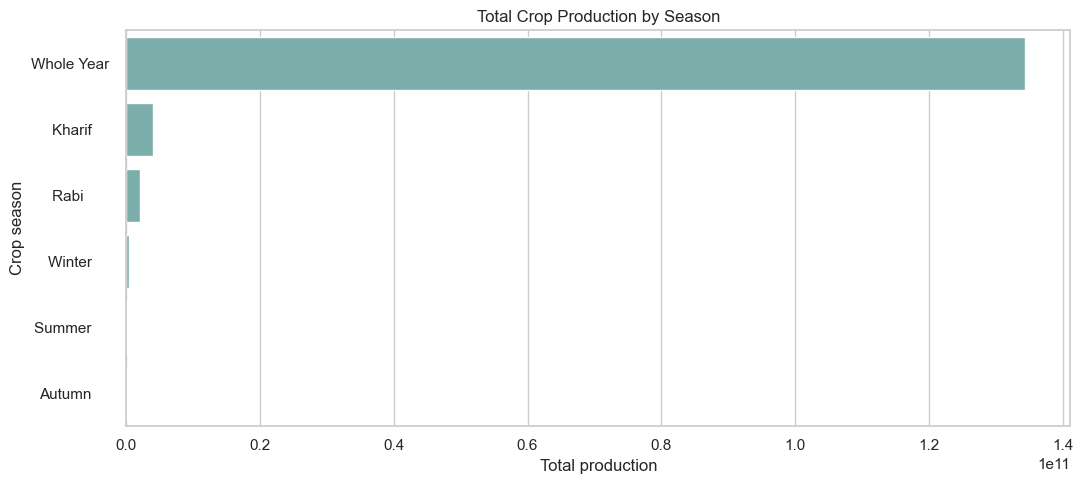

,City,AQI_clean
0,Ahmedabad,336.380040
10,Delhi,250.747138
21,Patna,229.776103
12,Gurugram,217.997618
19,Lucknow,213.469886
23,Talcher,160.404865
16,Jorapokhar,148.783576
6,Brajrajnagar,143.496802
13,Guwahati,137.151394
18,Kolkata,136.584767


,Pollutant,Average level
0,PM10,111.529814
1,PM2.5,64.495018
2,O3,33.794051
3,NOx,31.738348
4,NO2,28.038496
5,NH3,21.785599
6,NO,17.586426
7,SO2,15.120249
8,Toluene,7.250242
9,Benzene,2.879523


,Season,Production
4,Whole Year,1.344379e+11
1,Kharif,4.034225e+09
2,Rabi,2.052594e+09
5,Winter,4.345508e+08
3,Summer,1.708023e+08
0,Autumn,6.452057e+07


In [13]:
# Extra chart 1 - Top cities by average cleaned AQI
city_aqi = (
    air.groupby("City", as_index=False)["AQI_clean"]
    .mean()
    .sort_values("AQI_clean", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=city_aqi, x="AQI_clean", y="City", color="#E45756")
plt.title("Top 10 Cities by Average Cleaned AQI")
plt.xlabel("Average cleaned AQI")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Extra chart 2 - Average pollutant levels across all city-day records
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]
available_pollutants = [col for col in pollutant_cols if col in air.columns]

if available_pollutants:
    pollutant_means = (
        air[available_pollutants]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    pollutant_means.columns = ["Pollutant", "Average level"]

    plt.figure(figsize=(11, 5))
    sns.barplot(data=pollutant_means, x="Pollutant", y="Average level", color="#4C78A8")
    plt.title("Average Pollutant Levels")
    plt.xlabel("Pollutant")
    plt.ylabel("Average recorded level")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No pollutant columns were available for the pollutant-level chart.")

# Extra chart 3 - Weekday vs weekend AQI comparison
air["Day_Type"] = np.where(air["Date"].dt.dayofweek >= 5, "Weekend", "Weekday")

plt.figure(figsize=(8, 5))
sns.boxplot(data=air, x="Day_Type", y="AQI_clean", order=["Weekday", "Weekend"], palette=["#54A24B", "#F58518"])
plt.title("Weekday vs Weekend AQI")
plt.xlabel("Day type")
plt.ylabel("Cleaned AQI")
plt.tight_layout()
plt.show()

# Extra chart 4 - Crop production by season
season_production = (
    crop.groupby("Season", as_index=False)["Production"]
    .sum()
    .sort_values("Production", ascending=False)
    .head(8)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=season_production, x="Production", y="Season", color="#72B7B2")
plt.title("Total Crop Production by Season")
plt.xlabel("Total production")
plt.ylabel("Crop season")
plt.tight_layout()
plt.show()

display(city_aqi)
if available_pollutants:
    display(pollutant_means)
display(season_production)


**Response to the NGO:**  
The monthly and seasonal averages show whether October-December has the highest pollution in this dataset. If the harvest/post-monsoon group ranks first, the data supports the NGO's claim. If another season ranks higher, the claim is only partly supported or not supported by this sample. This analysis shows pattern, not cause, because weather, wind, traffic, industry, and monitoring coverage are not controlled here.


# Task 8 - Can the two datasets talk to each other?

The datasets cannot be joined row-by-row because their levels are different:

- Air quality: city-day records
- Crop production: district/crop/year records

The statistically best transformation is `State-Year`: air quality becomes average AQI by state and year, while crop production becomes total area, total production, and production per area by state and year.

However, the actual provided files have a serious mismatch. Air data runs from 2015-2020, while crop data runs from 1997-2015. In 2015, crop records are available only for Odisha and Sikkim, and the Odisha air-quality cities in this file do not have 2015 readings. So the exact `State-Year` merge may be empty.

To still explore the lab question honestly, the code below first attempts the correct `State-Year` merge. If no rows match, it falls back to a broader `State`-level exploratory merge using each state's average air quality over available air years and average crop output over available crop years.


In [14]:
air_state_year = (
    air.dropna(subset=["State", "Year"])
       .groupby(["State", "Year"], as_index=False)
       .agg(
           Avg_AQI=("AQI_clean", "mean"),
           Avg_PM25=("PM2.5", "mean"),
           Avg_PM10=("PM10", "mean"),
           Avg_NO2=("NO2", "mean"),
           City_Count=("City", "nunique")
       )
)

crop_state_year = (
    crop.groupby(["State", "Crop_Year"], as_index=False)
        .agg(
            Total_Area=("Area", "sum"),
            Total_Production=("Production", "sum"),
            Crop_Count=("Crop", "nunique"),
            District_Count=("District_Name", "nunique")
        )
        .rename(columns={"Crop_Year": "Year"})
)

crop_state_year["Production_per_Area"] = crop_state_year["Total_Production"] / crop_state_year["Total_Area"].replace(0, np.nan)

merged_state_year = pd.merge(air_state_year, crop_state_year, on=["State", "Year"], how="inner")

air_state = (
    air_state_year.groupby("State", as_index=False)
    .agg(
        Avg_AQI=("Avg_AQI", "mean"),
        Avg_PM25=("Avg_PM25", "mean"),
        Avg_PM10=("Avg_PM10", "mean"),
        Avg_NO2=("Avg_NO2", "mean"),
        City_Count=("City_Count", "max"),
        Air_Years=("Year", "nunique")
    )
)

crop_state = (
    crop_state_year.groupby("State", as_index=False)
    .agg(
        Total_Area=("Total_Area", "mean"),
        Total_Production=("Total_Production", "mean"),
        Production_per_Area=("Production_per_Area", "mean"),
        Crop_Count=("Crop_Count", "max"),
        District_Count=("District_Count", "max"),
        Crop_Years=("Year", "nunique")
    )
)

merged_state = pd.merge(air_state, crop_state, on="State", how="inner")

if len(merged_state_year) > 0:
    merged = merged_state_year.copy()
    merge_level = "State-Year"
else:
    merged = merged_state.copy()
    merge_level = "State fallback"

print("Air state-year shape:", air_state_year.shape)
print("Crop state-year shape:", crop_state_year.shape)
print("Exact State-Year merged shape:", merged_state_year.shape)
print("State-level fallback merged shape:", merged_state.shape)
print("Analysis level being used:", merge_level)
if "Year" in merged.columns:
    print("Years available after exact merge:", sorted(merged["Year"].unique()))
display(merged.head())


Air state-year shape: (91, 7)
Crop state-year shape: (519, 7)
Exact State-Year merged shape: (0, 12)
State-level fallback merged shape: (20, 13)
Analysis level being used: State fallback


,State,Avg_AQI,Avg_PM25,Avg_PM10,Avg_NO2,City_Count,Air_Years,Total_Area,Total_Production,Production_per_Area,Crop_Count,District_Count,Crop_Years
0,Andhra Pradesh,104.714579,42.327271,91.348995,31.903662,2,5,7.308102e+06,9.624820e+08,129.114799,59,13,18
1,Assam,142.247923,65.824917,118.804196,13.751048,1,2,3.909931e+06,1.173195e+08,34.553641,35,27,18
2,Bihar,226.278401,114.665775,119.250000,35.356691,1,6,7.126224e+06,2.036152e+07,2.868354,39,38,18
3,Chandigarh,102.615206,44.084711,90.374177,11.424800,1,2,9.632308e+02,4.923115e+03,5.010808,11,1,13
4,Gujarat,325.581479,63.108203,109.159116,53.428078,1,6,9.684002e+06,3.277176e+07,3.358076,29,26,16


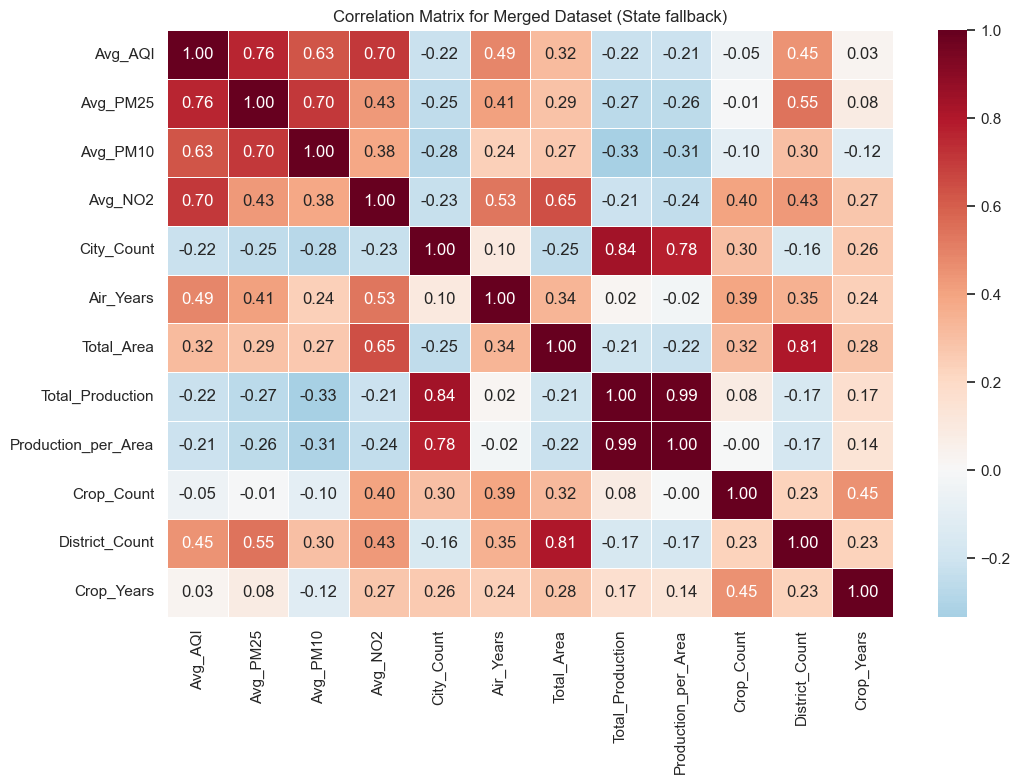

,Correlation with Avg_AQI
Avg_AQI,1.000000
Avg_PM25,0.761031
Avg_NO2,0.704289
Avg_PM10,0.627450
Air_Years,0.487525
District_Count,0.447803
Total_Area,0.316361
Crop_Years,0.026855
Crop_Count,-0.048561
Production_per_Area,-0.209777


In [15]:
numeric_cols = merged.select_dtypes(include=np.number).columns
corr = merged[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title(f"Correlation Matrix for Merged Dataset ({merge_level})")
plt.tight_layout()
plt.show()

display(corr["Avg_AQI"].sort_values(ascending=False).to_frame("Correlation with Avg_AQI"))


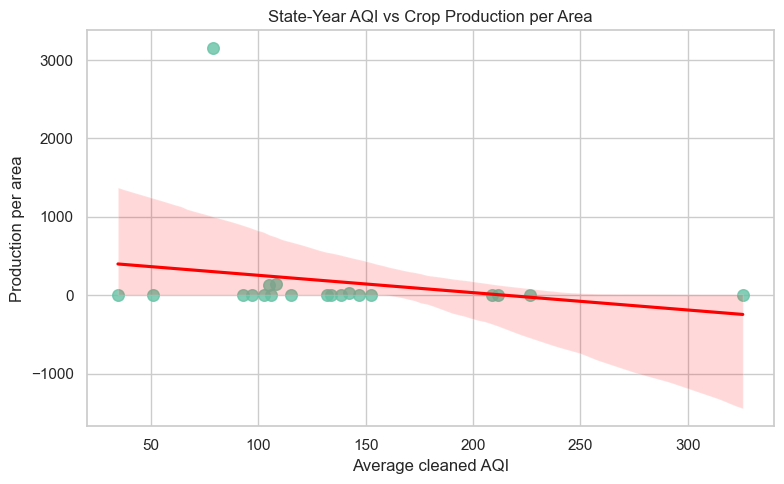

In [16]:
if len(merged) > 1:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=merged, x="Avg_AQI", y="Production_per_Area", scatter_kws={"s": 70}, line_kws={"color": "red"})
    plt.title("State-Year AQI vs Crop Production per Area")
    plt.xlabel("Average cleaned AQI")
    plt.ylabel("Production per area")
    plt.tight_layout()
    plt.show()
else:
    print("The merged data has too few rows for a reliable scatter/regression plot.")


**Two relationships to discuss:**  
1. `Avg_AQI` versus `Production_per_Area` is the central relationship. A negative value would suggest more polluted states tend to have lower output per area, but it does not prove pollution caused the decline.  
2. `Total_Area` and `Total_Production` are expected to be positively related because states cultivating more land usually produce more total crop output. This relationship is partly structural, not necessarily environmental.

Important limitation: because the exact state-year overlap is not available in the provided files, the fallback state-level merge compares averages from different time windows. This is useful for exploration, but it is not strong evidence for cause and effect.


# Task 9 - Minister briefing

Madam Minister, our analysis found three useful signals. First, many city-day readings sit in the moderate-to-poor AQI range, meaning air pollution is not limited to only a few isolated observations. Second, the AQI average is affected by extreme high readings, so public reporting should include both the average and the middle value to avoid exaggeration or understatement. Third, pollution changes by month, with the harvest/post-monsoon period needing special attention if it ranks among the highest AQI periods in the monthly chart.

For farmers, this matters because poor air often overlaps with periods of field activity, transport, and crop-residue burning. I recommend targeted state-level monitoring and residue-management support during high-risk months, especially in states where AQI remains high.

This evidence is useful but not conclusive. The crop and air datasets overlap weakly in time, and crop output also depends on rainfall, irrigation, soil, crop type, pests, and market conditions. The data supports action on monitoring and prevention, but not a final claim that pollution alone reduces crop yield.


# Optional Task A - Pollution extremes and crop output

This compares the most polluted and least polluted states in the merged data. Because the merged data is limited, treat this as exploratory evidence.


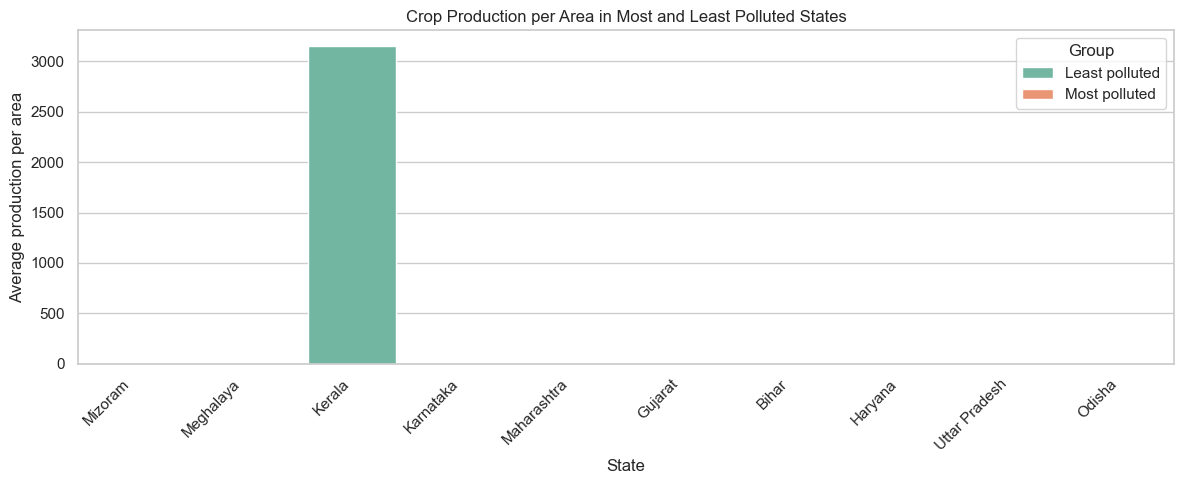

,State,Avg_AQI,Avg_Production_per_Area,Avg_Total_Production,Group
12,Mizoram,34.557522,1.657891,1.278768e+05,Least polluted
11,Meghalaya,50.978443,2.989920,6.729164e+05,Least polluted
8,Kerala,78.626690,3149.099889,5.437788e+09,Least polluted
7,Karnataka,92.723974,4.261214,4.796870e+07,Least polluted
10,Maharashtra,97.123485,3.903565,7.020885e+07,Least polluted
4,Gujarat,325.581479,3.358076,3.277176e+07,Most polluted
2,Bihar,226.278401,2.868354,2.036152e+07,Most polluted
5,Haryana,211.531161,4.410366,2.470258e+07,Most polluted
18,Uttar Pradesh,208.754703,7.555149,1.796945e+08,Most polluted
13,Odisha,152.366277,1.518298,8.479947e+06,Most polluted


In [17]:
if len(merged) >= 2:
    state_pollution = merged.groupby("State", as_index=False).agg(
        Avg_AQI=("Avg_AQI", "mean"),
        Avg_Production_per_Area=("Production_per_Area", "mean"),
        Avg_Total_Production=("Total_Production", "mean")
    )
    low_states = state_pollution.nsmallest(5, "Avg_AQI").assign(Group="Least polluted")
    high_states = state_pollution.nlargest(5, "Avg_AQI").assign(Group="Most polluted")
    extremes = pd.concat([low_states, high_states])

    plt.figure(figsize=(12, 5))
    sns.barplot(data=extremes, x="State", y="Avg_Production_per_Area", hue="Group")
    plt.title("Crop Production per Area in Most and Least Polluted States")
    plt.xlabel("State")
    plt.ylabel("Average production per area")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(extremes)
else:
    print("Not enough merged rows for optional extreme-state comparison.")


# Optional Task B - Put a number on the relationship

Pearson correlation measures the direction and strength of a linear relationship. It does not prove causation.


In [18]:
if len(merged) >= 3:
    relationship = merged[["Avg_AQI", "Production_per_Area"]].corr().iloc[0, 1]
    print("Correlation between Avg_AQI and Production_per_Area:", round(relationship, 3))
else:
    print("Too few merged rows for a meaningful correlation value.")


Correlation between Avg_AQI and Production_per_Area: -0.21


# Optional Task C - One plot to rule them all

For the single most powerful visual, I choose **AQI vs Crop Production per Area**.

This plot is the best choice because it directly connects the lab's central question: do places with dirtier air also show weaker agricultural output? Since the exact `State-Year` merge was not available in the provided files, the chart uses the cleaned merged dataset created in Task 8. In this notebook, that is the transparent **state-level fallback** dataset.


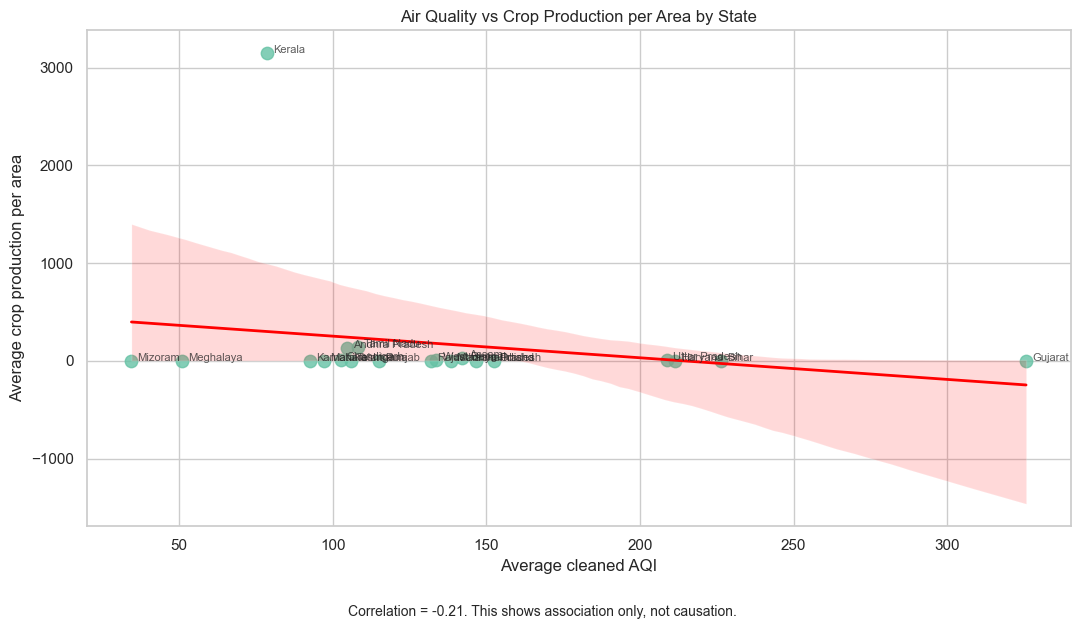

Correlation between AQI and crop production per area: -0.210


In [19]:
if len(merged) >= 2:
    plot_data = merged.copy()
    corr_value = plot_data[["Avg_AQI", "Production_per_Area"]].corr().iloc[0, 1]

    plt.figure(figsize=(11, 6))
    sns.regplot(
        data=plot_data,
        x="Avg_AQI",
        y="Production_per_Area",
        scatter_kws={"s": 80, "alpha": 0.8},
        line_kws={"color": "red", "linewidth": 2}
    )

    # Label each point so the chart can stand alone in a report.
    for _, row in plot_data.iterrows():
        plt.text(
            row["Avg_AQI"] + 2,
            row["Production_per_Area"],
            row["State"],
            fontsize=8,
            alpha=0.75
        )

    plt.title("Air Quality vs Crop Production per Area by State")
    plt.xlabel("Average cleaned AQI")
    plt.ylabel("Average crop production per area")
    plt.figtext(
        0.5,
        -0.04,
        f"Correlation = {corr_value:.2f}. This shows association only, not causation.",
        ha="center",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    print(f"Correlation between AQI and crop production per area: {corr_value:.3f}")
else:
    print("Not enough merged records to create the final story chart.")


**Final caption:**  
This chart brings the air-agriculture question into one view: states with higher average AQI are compared against their average crop production per area. The line suggests only a weak negative relationship in the available data, so the pattern is not strong enough to claim that pollution directly reduces crop yield. Its real value is that it shows both the possible concern and the data limitation at the same time. Rainfall, irrigation, soil quality, crop mix, economic conditions, and the mismatch in years could also explain differences in production, so this chart should be treated as evidence for further investigation, not final proof of causation.


## Final checklist

- Tasks are numbered.
- Code cells are commented and grouped by task.
- Markdown reasoning is included for every task.
- More than five visualisations are included.
- Axes and titles are provided.
- Data limitations are stated honestly.
